In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow import keras
from tensorflow.keras import layers

In [6]:
X, y = load_breast_cancer(return_X_y=True, as_frame=True)

print(X.head())
print("X shape:", X.shape)

print("\nKlassfördelning:")
print(y.value_counts())

   mean radius  mean texture  ...  worst symmetry  worst fractal dimension
0        17.99         10.38  ...          0.4601                  0.11890
1        20.57         17.77  ...          0.2750                  0.08902
2        19.69         21.25  ...          0.3613                  0.08758
3        11.42         20.38  ...          0.6638                  0.17300
4        20.29         14.34  ...          0.2364                  0.07678

[5 rows x 30 columns]
X shape: (569, 30)

Klassfördelning:
target
1    357
0    212
Name: count, dtype: int64


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (455, 30)
Test shape: (114, 30)


In [8]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled Train shape:", X_train_scaled.shape)
print("Scaled Test shape:", X_test_scaled.shape)

Scaled Train shape: (455, 30)
Scaled Test shape: (114, 30)


In [10]:
model = keras.Sequential([
    layers.Dense(16, activation="relu", input_shape=(X_train_scaled.shape[1], )),
    layers.Dense(8, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 16)             │           496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 641 (2.50 KB)

 Trainable params: 641 (2.50 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [12]:
history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    verbose=1
)

Epoch 1/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6676 - loss: 0.6475 - val_accuracy: 0.7143 - val_loss: 0.5907
Epoch 2/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7527 - loss: 0.5479 - val_accuracy: 0.8132 - val_loss: 0.4978
Epoch 3/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8132 - loss: 0.4635 - val_accuracy: 0.8571 - val_loss: 0.4250
Epoch 4/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8571 - loss: 0.3921 - val_accuracy: 0.8681 - val_loss: 0.3630
Epoch 5/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8874 - loss: 0.3310 - val_accuracy: 0.9231 - val_loss: 0.3119
Epoch 6/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9066 - loss: 0.2821 - val_accuracy: 0.9341 - val_loss: 0.2690
Epoch 7/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9093 - loss: 0.2456 - val_accuracy: 0.9670 - val_loss: 0.2345
Epoch 8/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9203 - loss: 0.2188 - val_accuracy: 0.9670 - val_loss

In [15]:
test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")

Test loss: 0.1431
Test accuracy: 0.9561


In [16]:
y_pred_proba = model.predict(X_test_scaled)

y_pred_class = (y_pred_proba >= 0.5).astype(int)

print("Första 10 sannolikheter:\n", y_pred_proba[:10].flatten())
print("\nFörsta 10 klassprediktioner:\n", y_pred_class[:10].flatten())

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
Första 10 sannolikheter:
 [4.5803993e-04 9.9984950e-01 6.0950220e-02 5.9057617e-01 7.5178249e-03
 9.8479247e-01 9.9948782e-01 3.9706538e-03 5.0203647e-02 1.0221639e-05]

Första 10 klassprediktioner:
 [0 1 0 1 0 1 1 0 0 0]


In [17]:
cm = confusion_matrix(y_test, y_pred_class)

print("Confusion matrix:")
print(cm)

print("\nClassification report:")
print(classification_report(y_test, y_pred_class))

Confusion matrix:
[[40  2]
 [ 3 69]]

Classification report:
              precision    recall  f1-score   support

           0       0.93      0.95      0.94        42
           1       0.97      0.96      0.97        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



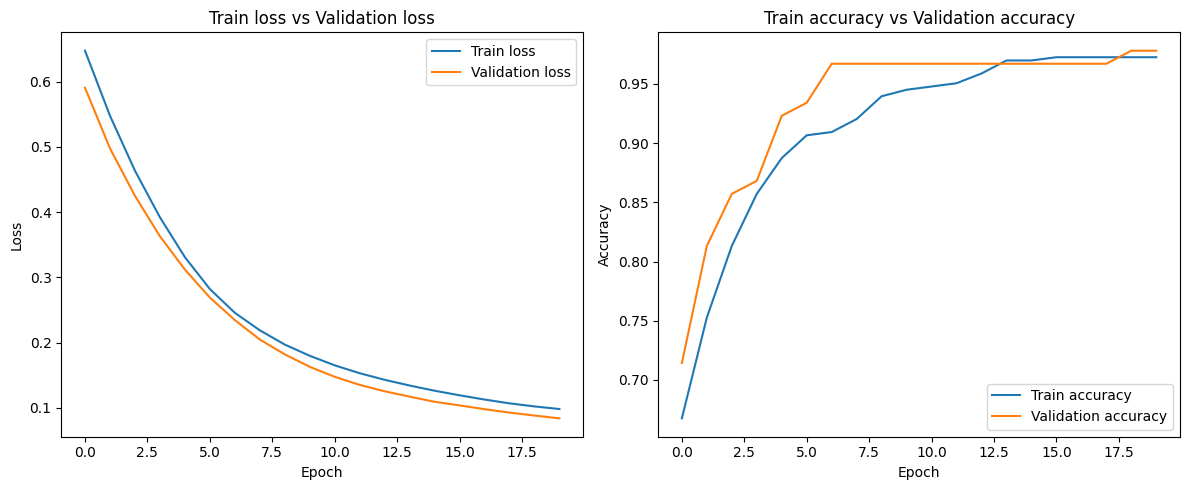

In [18]:
plt.figure(figsize=(12,5))

# Loss
plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="Train loss")
plt.plot(history.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train loss vs Validation loss")
plt.legend()

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"], label="Train accuracy")
plt.plot(history.history["val_accuracy"], label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Train accuracy vs Validation accuracy")
plt.legend()

plt.tight_layout()
plt.show()

In [19]:
result_df = pd.DataFrame({
    "True label": y_test.reset_index(drop=True),
    "Predicted probabililty": y_pred_proba.flatten(),
    "Predicted class": y_pred_class.flatten()
})

print(result_df.head(10))

   True label  Predicted probabililty  Predicted class
0           0                0.000458                0
1           1                0.999849                1
2           0                0.060950                0
3           1                0.590576                1
4           0                0.007518                0
5           1                0.984792                1
6           1                0.999488                1
7           0                0.003971                0
8           0                0.050204                0
9           0                0.000010                0
